link prediction on KG

CopyRight by dr.seungchul@gmail.com


In [1]:
import os
import torch
import itertools
os.environ['TORCH'] = torch.__version__
os.environ['PYTHONWARNINGS'] = "ignore"
!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git
!pip install torch-geometric
!pip3 install kmeans1d
from torch_geometric.data import Data
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv, GATConv
from torch.utils.data import TensorDataset, DataLoader
import torch_geometric.transforms as T
import sys
import random
import numpy as np
import time
import math
import csv
import datetime
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import glob
import random
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from tqdm.notebook import tqdm
from math import exp
from chardet import detect
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import degree
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
from networkx.algorithms import bipartite
import kmeans1d
import copy
from google.colab import drive
from torch_geometric.utils import to_networkx
import networkx as nx
from sklearn.metrics import roc_auc_score
from torch_geometric.utils import negative_sampling, train_test_split_edges

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 53.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 29.4 MB/s eta 0:00:00
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-aqi7m7pl
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-aqi7m7pl
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit 1f0fbe89d654232fdc949d7b947b938671657c31
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch-geometric: filename=torch_geometric-2.7.0-py3-none-any.whl size=1234822 sha256=26e57103b01e82a12aef3773f24bde20c5ac3373954bee77eb974e89f4636042
  Stored in directory: /tmp/pip-ephem-wheel-cache-dvwh9_t2/wheels/9

In [17]:
# hyperparameters
HID_DIM = 16
EPOCHS = 2000
LEARNING_RATE = 0.0001
HEADS =16
DROPOUT = 0.3
TEST_SIZE = 0
VAL_SIZE = 0

In [32]:
# read files
df_node = pd.read_csv('kgn0.csv')
node_feats = df_node.columns[2:]
node_ids = df_node['title'].unique()
le_node = pp.LabelEncoder().fit(node_ids)
df_node['node_idx'] = le_node.transform(node_ids)
labels = df_node['label'].unique()
num_classes = len(labels)

df_edge = pd.read_csv("kge0.csv")
edge_feats = df_edge.columns[2:]
df_edge['src_idx'] = le_node.transform(df_edge['src'])
df_edge['dst_idx'] = le_node.transform(df_edge['dst'])

print(50*'*')
print('Number of nodes', len(node_ids))
print('Number of node feauturs', len(node_feats))
print('Number of node classes', num_classes)
print('Number of edges', len(df_edge))
print('Number of edge feauturs', len(edge_feats))

**************************************************
Number of nodes 26
Number of node feauturs 3
Number of node classes 5
Number of edges 35
Number of edge feauturs 2


In [33]:
# graph
x = []
for i, row in df_node.iterrows():
  feats = row[2:2+len(node_feats)]
  x.append(feats)
x = torch.tensor(x, dtype=torch.float)

le_label = pp.LabelEncoder().fit(labels)
y = le_label.transform(df_node['label']).tolist()
y = torch.tensor(y)

srcs = list(df_edge['src_idx'])
dsts = list(df_edge['dst_idx'])
zip1 = list(zip(srcs, dsts))
zip1 = [list(item) for item in zip1]
zip2 = list(zip(dsts, srcs))
zip2 = [list(item) for item in zip2]
zipped = zip1+zip2
edge_index = torch.tensor(zipped)

e_f = []
for i, row in df_edge.iterrows():
  feats = row[2:2+len(edge_feats)]
  e_f.append(feats)
e_f = e_f + e_f
edge_attr = torch.tensor(e_f, dtype=torch.float)

graph = Data(x=x, edge_index=edge_index.t().contiguous(), y=y, edge_attr=edge_attr)
graph.num_nodes = len(node_ids)
graph.num_edges = len(df_edge)
graph.num_classes = num_classes
graph.node_feats = graph.x.shape[1]
graph.edge_feats = graph.edge_attr.shape[1]
graph.validate(raise_on_error=True)
graph

/tmp/ipython-input-801808574.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(x, dtype=torch.float)
/tmp/ipython-input-801808574.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  edge_attr = torch.tensor(e_f, dtype=torch.float)


Data(x=[26, 3], edge_index=[2, 70], edge_attr=[70, 2], y=[26], num_nodes=26, num_edges=35, num_classes=5, node_feats=3, edge_feats=2)

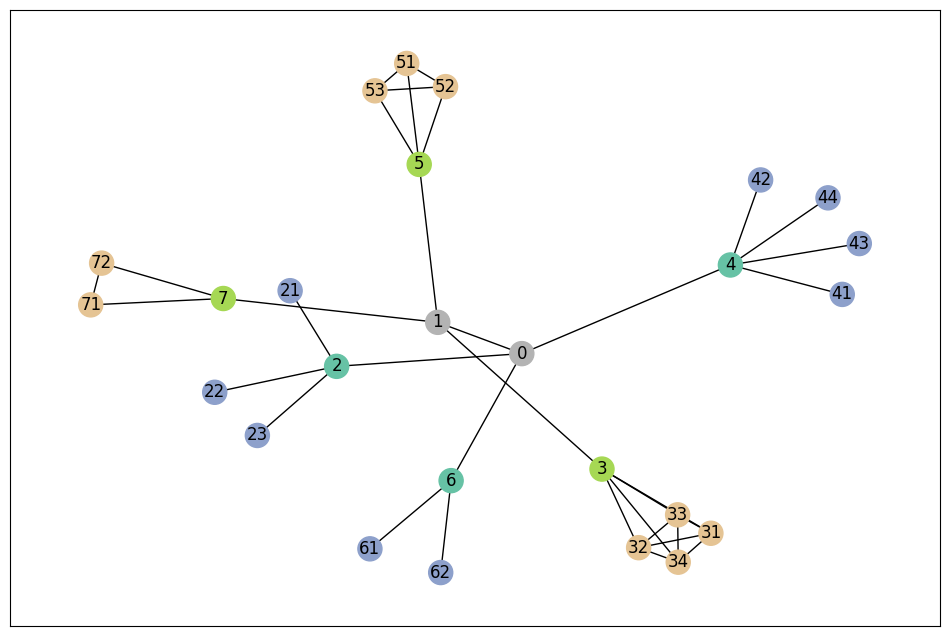

In [34]:
G = to_networkx(graph, to_undirected=True)
plt.figure(figsize=(12,8))
node_labels = {i: df_node.loc[df_node['node_idx'] == i, 'title'].iloc[0] for i in G.nodes}
node_colors = {i: df_node.loc[df_node['node_idx'] == i, 'label'].iloc[0] for i in G.nodes}
node_colors = list(node_colors.values())
nx.draw_networkx(G, pos=nx.spring_layout(G, seed=5441), with_labels=True, node_color=node_colors, cmap="Set2", labels=node_labels)
plt.show()


In [35]:
split = T.RandomLinkSplit(num_val=VAL_SIZE, num_test=TEST_SIZE, is_undirected=True, add_negative_train_samples=False, neg_sampling_ratio=1.0)
train_data, val_data, test_data = split(graph)
#print(graph.edge_index)
#print(train_data.edge_label_index)
#print(val_data.edge_label_index)
#print(test_data.edge_label_index)
#print(test_data.edge_label)


In [36]:
class LinkPredictor(nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super(LinkPredictor, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

    def forward(self, x, edge_index):  # 노드 임베딩 계산
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=DROPOUT, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def predict_edges(self, z, edge_label_index): # link score 계산
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=-1)

model = LinkPredictor(graph.node_feats, HID_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

model.train()
for epoch in range(EPOCHS):
  z = model(train_data.x, train_data.edge_index)
  pos_edge_index = train_data.edge_index
  neg_edge_index = negative_sampling(edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
                                       num_neg_samples=train_data.edge_index.size(1), method='sparse')
  pos_pred = model.predict_edges(z, pos_edge_index)
  neg_pred = model.predict_edges(z, neg_edge_index)
  pos_loss = F.binary_cross_entropy_with_logits(pos_pred, torch.ones(pos_pred.size(0)))
  neg_loss = F.binary_cross_entropy_with_logits(neg_pred, torch.zeros(neg_pred.size(0)))
  loss = pos_loss + neg_loss
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

model.eval()
with torch.no_grad():
  z = model(graph.x, graph.edge_index)

all_edges = torch.combinations(torch.arange(graph.num_nodes), 2).t()
pred = torch.sigmoid(model.predict_edges(z, all_edges))
#print(all_edges)
#print(pred.numpy())

LinkPredictor(
  (conv1): GCNConv(3, 16)
  (conv2): GCNConv(16, 16)
)


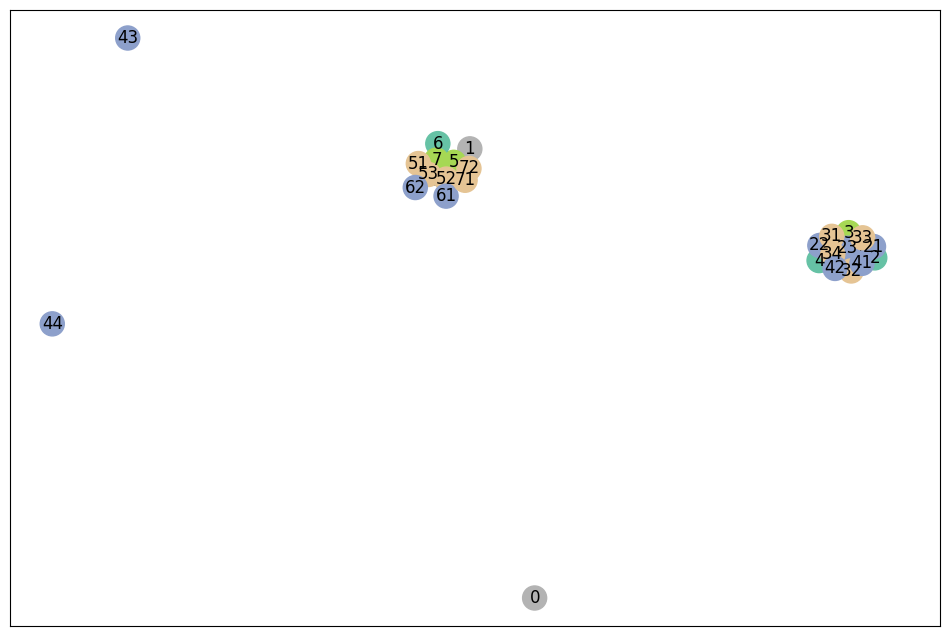

In [37]:
THRESHOLD = 0.57

srcs = []
dsts = []
for e, p in zip(all_edges.t().tolist(), pred.tolist()):
  if p > THRESHOLD:
    srcs.append(e[0])
    dsts.append(e[1])
    #print(e,p)

zip1 = list(zip(srcs, dsts))
zip1 = [list(item) for item in zip1]
zip2 = list(zip(dsts, srcs))
zip2 = [list(item) for item in zip2]
zipped = zip1+zip2
edge_index = torch.tensor(zipped)
edge_index=edge_index.t().contiguous()
graph.edge_index = edge_index

G = to_networkx(graph, to_undirected=True)
plt.figure(figsize=(12,8))
node_labels = {i: df_node.loc[df_node['node_idx'] == i, 'title'].iloc[0] for i in G.nodes}
node_colors = {i: df_node.loc[df_node['node_idx'] == i, 'label'].iloc[0] for i in G.nodes}
node_colors = list(node_colors.values())
nx.draw_networkx(G, pos=nx.spring_layout(G, seed=218), with_labels=True, node_color=node_colors, cmap="Set2", labels=node_labels)
plt.show()

In [12]:
while True:
  print(50*"-")
  u = input("first node: ")
  if u == "":
    break
  v = input("second node: ")
  if v == "":
    break
  u = df_node[df_node['title'] == u]['node_idx'].iloc[0]
  v = df_node[df_node['title'] == v]['node_idx'].iloc[0]
  edge_uv = torch.tensor([[u], [v]])
  prob_uv = model.predict_edges(z, edge_uv).sigmoid().item()
  print(f'The probability of a link is: {prob_uv:.4f}')


--------------------------------------------------
first node: n0
second node: n2
The probability of a link is: 0.2604
--------------------------------------------------
first node: 


GCNLinkPred(
  (conv0): GCNConv(3, 16)
  (conv1): GCNConv(16, 32)
)


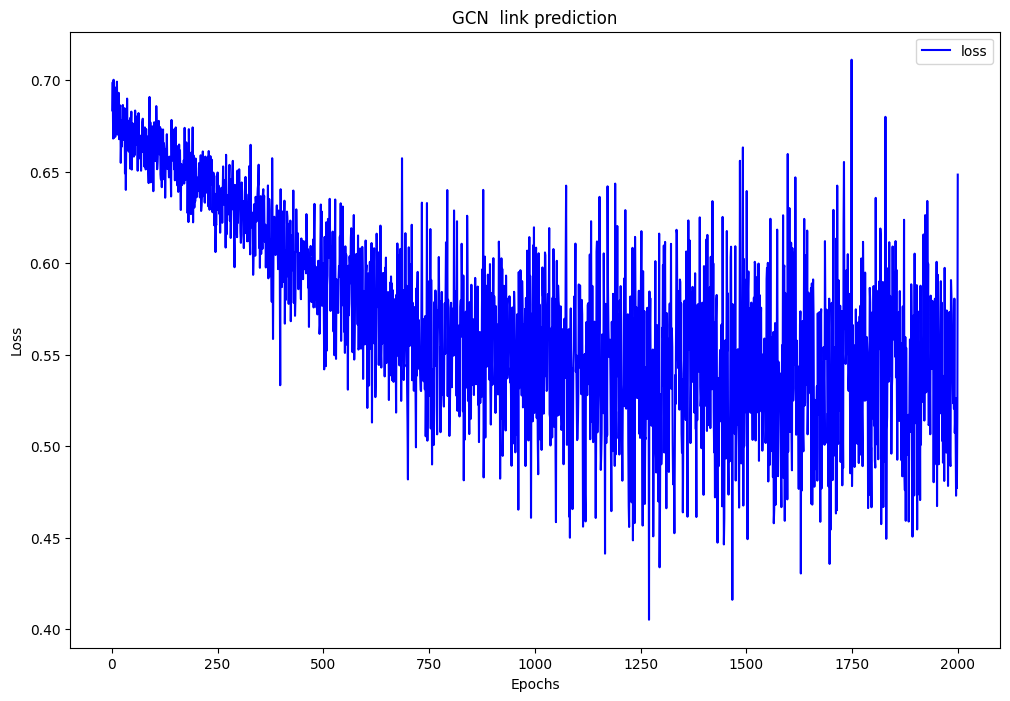

In [38]:
class GCNLinkPred(torch.nn.Module):
    def __init__(self, input_dim, hid_dim, output_dim):
        super(GCNLinkPred, self).__init__()
        self.conv0 = GCNConv(input_dim, hid_dim)
        self.conv1 = GCNConv(hid_dim, output_dim)

    def encode(self, x, edge_index):
        x = self.conv0(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=DROPOUT, training=self.training)
        x = self.conv1(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
      return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def decode_all(self, z):
      prob_adj = z @ z.t()
      return (prob_adj > 0).nonzero(as_tuple=False).t()

model = GCNLinkPred(graph.node_feats, HID_DIM, 32)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_function = torch.nn.BCEWithLogitsLoss()
print(model)

model.train()
losses=[]
for epoch in range(EPOCHS):
    z = model.encode(train_data.x, train_data.edge_index)
    neg_edge_index = negative_sampling(edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
                                       num_neg_samples=train_data.edge_label_index.size(1), method='sparse')
    edge_label_index = torch.cat([train_data.edge_label_index, neg_edge_index], dim=-1)
    edge_label = torch.cat([train_data.edge_label, train_data.edge_label.new_zeros(neg_edge_index.size(1))], dim=0)
    result = model.decode(z, edge_label_index).view(-1)
    loss = loss_function(result, edge_label)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

plt.figure(figsize=(12,8))
plt.title('GCN  link prediction')
plt.xlabel('Epochs')
plt.ylabel('Loss')
losses_np = np.array(losses)
epoch_range = np.arange(1,EPOCHS+1)
plt.plot(epoch_range, losses_np, color='blue', label='loss')
plt.legend()
plt.show()

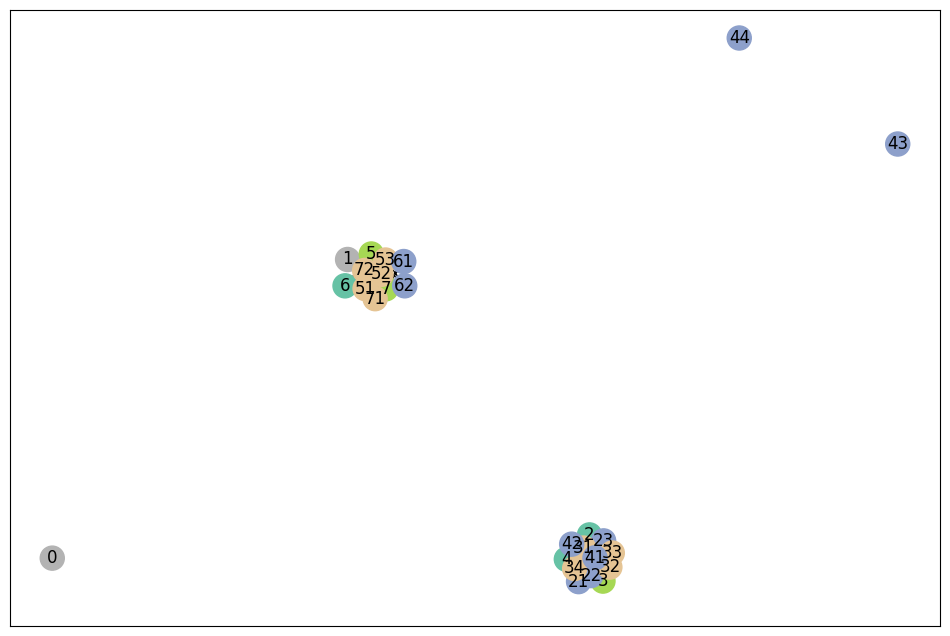

In [39]:
THRESHOLD = 0.57

srcs = []
dsts = []
for e, p in zip(all_edges.t().tolist(), pred.tolist()):
  if p > THRESHOLD:
    srcs.append(e[0])
    dsts.append(e[1])
    #print(e,p)

zip1 = list(zip(srcs, dsts))
zip1 = [list(item) for item in zip1]
zip2 = list(zip(dsts, srcs))
zip2 = [list(item) for item in zip2]
zipped = zip1+zip2
edge_index = torch.tensor(zipped)
edge_index=edge_index.t().contiguous()
graph.edge_index = edge_index

G = to_networkx(graph, to_undirected=True)
plt.figure(figsize=(12,8))
node_labels = {i: df_node.loc[df_node['node_idx'] == i, 'title'].iloc[0] for i in G.nodes}
node_colors = {i: df_node.loc[df_node['node_idx'] == i, 'label'].iloc[0] for i in G.nodes}
node_colors = list(node_colors.values())
nx.draw_networkx(G, pos=nx.spring_layout(G, seed=5441), with_labels=True, node_color=node_colors, cmap="Set2", labels=node_labels)
plt.show()

GATLinkPred(
  (conv1): GATConv(3, 16, heads=16)
  (conv2): GATConv(256, 5, heads=1)
)


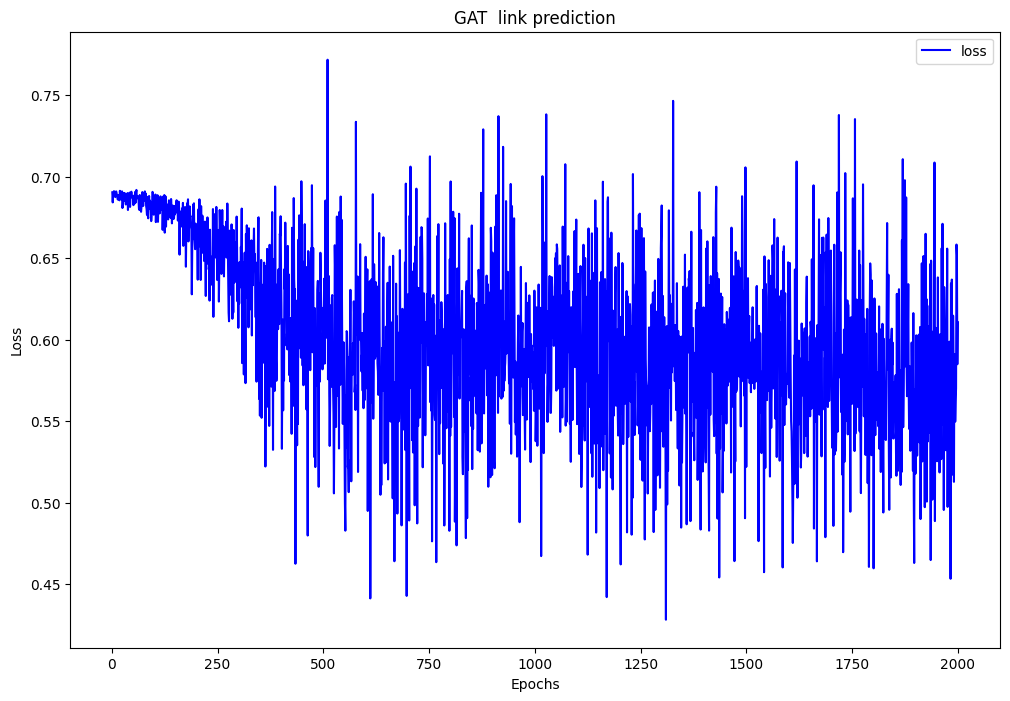

In [40]:
class GATLinkPred(torch.nn.Module):
    def __init__(self, input_dim, hid_dim, output_dim):
        super(GATLinkPred, self).__init__()
        self.conv1 = GATConv(input_dim, hid_dim, HEADS, dropout=DROPOUT)
        self.conv2 = GATConv(hid_dim*HEADS, output_dim, heads=1, concat=False, dropout=0)

    def encode(self, x, edge_index):
        x = F.dropout(x, p=DROPOUT, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=DROPOUT, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
      return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def decode_all(self, z):
      prob_adj = z @ z.t()
      return (prob_adj > 0).nonzero(as_tuple=False).t()

model = GATLinkPred(len(node_feats), HID_DIM, graph.num_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_function = torch.nn.BCEWithLogitsLoss()
print(model)

model.train()
losses=[]
for epoch in range(EPOCHS):
    z = model.encode(train_data.x, train_data.edge_index)
    neg_edge_index = negative_sampling(edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
                                       num_neg_samples=train_data.edge_label_index.size(1), method='sparse')
    edge_label_index = torch.cat([train_data.edge_label_index, neg_edge_index], dim=-1)
    edge_label = torch.cat([train_data.edge_label, train_data.edge_label.new_zeros(neg_edge_index.size(1))], dim=0)
    result = model.decode(z, edge_label_index).view(-1)
    loss = loss_function(result, edge_label)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

plt.figure(figsize=(12,8))
plt.title('GAT  link prediction')
plt.xlabel('Epochs')
plt.ylabel('Loss')
losses_np = np.array(losses)
epoch_range = np.arange(1,EPOCHS+1)
plt.plot(epoch_range, losses_np, color='blue', label='loss')
plt.legend()
plt.show()

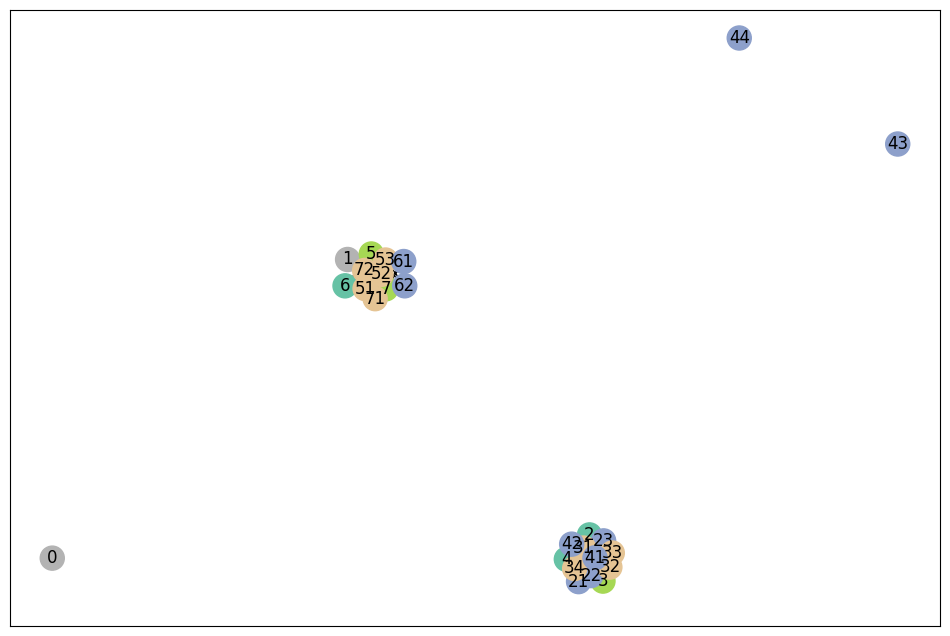

In [41]:
THRESHOLD = 0.57

srcs = []
dsts = []
for e, p in zip(all_edges.t().tolist(), pred.tolist()):
  if p > THRESHOLD:
    srcs.append(e[0])
    dsts.append(e[1])
    #print(e,p)

zip1 = list(zip(srcs, dsts))
zip1 = [list(item) for item in zip1]
zip2 = list(zip(dsts, srcs))
zip2 = [list(item) for item in zip2]
zipped = zip1+zip2
edge_index = torch.tensor(zipped)
edge_index=edge_index.t().contiguous()
graph.edge_index = edge_index

G = to_networkx(graph, to_undirected=True)
plt.figure(figsize=(12,8))
node_labels = {i: df_node.loc[df_node['node_idx'] == i, 'title'].iloc[0] for i in G.nodes}
node_colors = {i: df_node.loc[df_node['node_idx'] == i, 'label'].iloc[0] for i in G.nodes}
node_colors = list(node_colors.values())
nx.draw_networkx(G, pos=nx.spring_layout(G, seed=5441), with_labels=True, node_color=node_colors, cmap="Set2", labels=node_labels)
plt.show()